In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data  = pd.read_csv('STUDENTDATSETBS.csv')



In [3]:
data.head(5)

,Name,Age,Marks,Subject,Admission
0,Bilal Shah,20,584,Arts,No
1,Ayesha Farooq,17,650,Arts,No
2,Ali Shah,22,892,Math,Yes
3,Bilal Shah,19,901,Computer,Yes
4,Bilal Malik,19,531,Math,No


## understanding about data

In [78]:
data.head(3)

,Name,Age,Marks,Subject,Admission
0,Bilal Shah,20,584,Arts,No
1,Ayesha Farooq,17,650,Arts,No
2,Ali Shah,22,892,Math,Yes


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       997 non-null    object
 1   Age        997 non-null    int64 
 2   Marks      997 non-null    int64 
 3   Subject    997 non-null    object
 4   Admission  997 non-null    object
dtypes: int64(2), object(3)
memory usage: 46.7+ KB


In [4]:
data.shape

(1000, 5)

In [5]:
data['Subject'].value_counts()

Subject
Computer    320
Math        250
Medical     230
Arts        200
Name: count, dtype: int64

In [6]:
data['Admission'].value_counts()


Admission
Yes    523
No     477
Name: count, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       1000 non-null   object
 1   Age        1000 non-null   int64 
 2   Marks      1000 non-null   int64 
 3   Subject    1000 non-null   object
 4   Admission  1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [8]:
data.describe()

,Age,Marks
count,1000.000000,1000.000000
mean,18.982000,728.133000
std,2.009406,136.848715
min,16.000000,500.000000
25%,17.000000,606.000000
50%,19.000000,721.000000
75%,21.000000,838.250000
max,22.000000,998.000000


## Missing value checks

In [9]:
data.isnull().sum()

Name         0
Age          0
Marks        0
Subject      0
Admission    0
dtype: int64

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
data.duplicated().sum()

0

In [13]:
data.shape

(997, 5)

In [14]:
print(data['Age'].min())
print(data['Age'].max())

16
22


In [15]:
print(data['Marks'].min())
print(data['Marks'].max())

500
998


EDA

In [16]:
data_cat = data.select_dtypes(np.object_)
print(data_cat)

              Name   Subject Admission
0       Bilal Shah      Arts        No
1    Ayesha Farooq      Arts        No
2         Ali Shah      Math       Yes
3       Bilal Shah  Computer       Yes
4      Bilal Malik      Math        No
..             ...       ...       ...
995     Sara Ahmed   Medical       Yes
996     Iqra Ahmed      Math        No
997     Ayesha Ali  Computer       Yes
998     Ahmed Khan      Arts        No
999       Ali Butt      Math       Yes

[997 rows x 3 columns]


In [17]:
data_num = data.select_dtypes(np.number)
print(data_num)

     Age  Marks
0     20    584
1     17    650
2     22    892
3     19    901
4     19    531
..   ...    ...
995   18    955
996   17    688
997   21    992
998   17    758
999   22    592

[997 rows x 2 columns]


## categorical column eda

<Axes: xlabel='count', ylabel='Subject'>

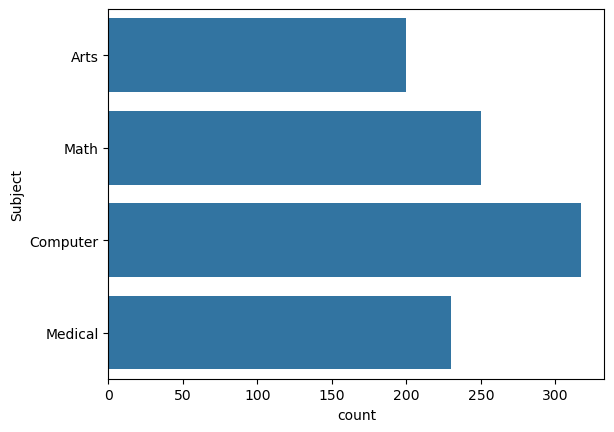

In [18]:
sns.countplot(data['Subject'])

<Axes: xlabel='count', ylabel='Admission'>

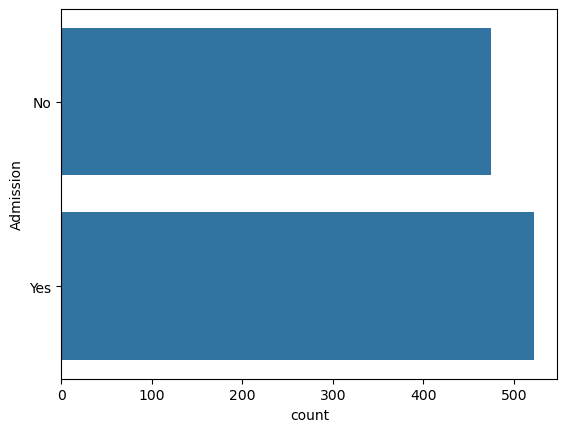

In [19]:
sns.countplot(data['Admission'])

<Axes: ylabel='count'>

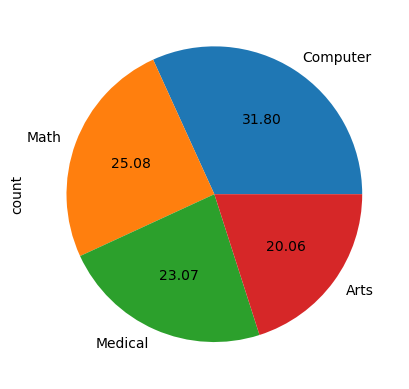

In [20]:

data['Subject'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

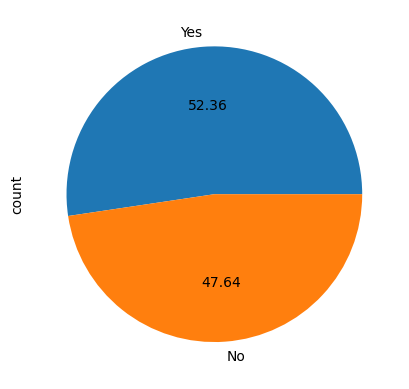

In [21]:

data['Admission'].value_counts().plot(kind='pie',autopct='%.2f')

## numerical column

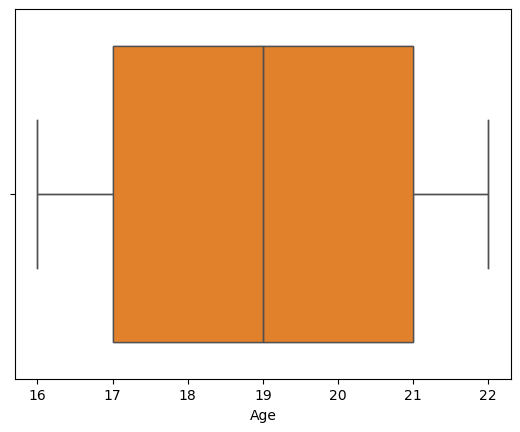

In [22]:
for  Col in data_num:
 plt.Figure(figsize=(6,4))
 sns.boxplot(x= data['Age'])

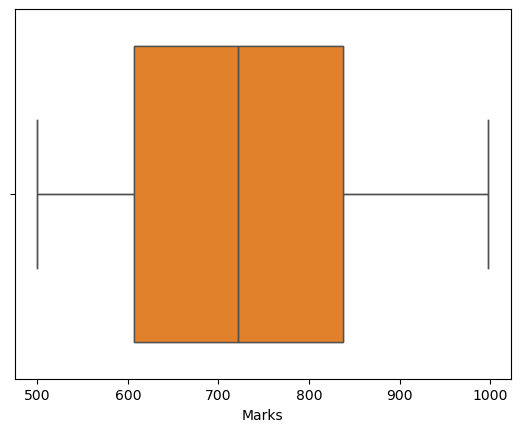

In [23]:
for  Col in data_num:
 plt.Figure(figsize=(6,4))
 sns.boxplot(x= data['Marks'])

In [24]:
print(data['Age'].skew())
print(data['Marks'].skew())

-0.009534956174834535
0.1307797863612998


Encoding applay

In [25]:
data.head(2)

,Name,Age,Marks,Subject,Admission
0,Bilal Shah,20,584,Arts,No
1,Ayesha Farooq,17,650,Arts,No


In [26]:
df = data.drop("Name", axis=1)


In [27]:
df.isnull().sum()

Age          0
Marks        0
Subject      0
Admission    0
dtype: int64

## Data preprocessing (Encoding)

In [28]:
df = pd.get_dummies(df,columns=["Subject"],drop_first=True)

In [29]:
df.head(2)

,Age,Marks,Admission,Subject_Computer,Subject_Math,Subject_Medical
0,20,584,No,False,False,False
1,17,650,No,False,False,False


In [30]:
df["Admission"] = df["Admission"].map({"Yes":1,"No":0})


In [31]:
df.isnull().sum()

Age                 0
Marks               0
Admission           0
Subject_Computer    0
Subject_Math        0
Subject_Medical     0
dtype: int64

In [32]:
print(df.nunique())

Age                   7
Marks               426
Admission             2
Subject_Computer      2
Subject_Math          2
Subject_Medical       2
dtype: int64


In [33]:
df.tail(3)

,Age,Marks,Admission,Subject_Computer,Subject_Math,Subject_Medical
997,21,992,1,True,False,False
998,17,758,0,False,False,False
999,22,592,1,False,True,False


In [34]:
df = df.astype(int)

In [35]:
df.corr()

,Age,Marks,Admission,Subject_Computer,Subject_Math,Subject_Medical
Age,1.000000,0.041044,0.527356,-0.051685,0.048412,0.009211
Marks,0.041044,1.000000,0.265658,0.044696,-0.038140,0.046153
Admission,0.527356,0.265658,1.000000,0.133809,0.111694,0.179140
Subject_Computer,-0.051685,0.044696,0.133809,1.000000,-0.394989,-0.373888
Subject_Math,0.048412,-0.038140,0.111694,-0.394989,1.000000,-0.316793
Subject_Medical,0.009211,0.046153,0.179140,-0.373888,-0.316793,1.000000


## train data part

In [36]:
x = df.drop('Admission',axis=1)
y= df['Admission']

In [37]:
x.head(2)

,Age,Marks,Subject_Computer,Subject_Math,Subject_Medical
0,20,584,0,0,0
1,17,650,0,0,0


In [38]:
y.tail(2)

998    0
999    1
Name: Admission, dtype: int32

## train model

In [39]:
from sklearn .model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
print(x_train.head(2))
print(x_test.head(2))



     Age  Marks  Subject_Computer  Subject_Math  Subject_Medical
743   17    659                 1             0                0
286   22    881                 0             0                1
     Age  Marks  Subject_Computer  Subject_Math  Subject_Medical
453   20    559                 0             0                1
793   21    702                 0             0                1


In [41]:
y_train.head(2)

743    0
286    1
Name: Admission, dtype: int32

In [42]:
y_test.head(2)

453    1
793    1
Name: Admission, dtype: int32

In [43]:
from sklearn .preprocessing import StandardScaler
scalar = StandardScaler()
x_train_scalar =  scalar.fit_transform(x_train[["Age","Marks"]])
x_test_scalar =  scalar.fit_transform(x_test[["Age","Marks"]])

## Algorithm apply

## logistic regression
## standard salar

In [44]:
from sklearn . linear_model import LogisticRegression
model_log = LogisticRegression()
model_log.fit(x_train_scalar,y_train)
y_pred1 = model_log.predict(x_test_scalar)
print(y_pred1)

[0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1
 0 1 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1
 1 1 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 1 1
 1 1 0 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0
 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1]


## accuracy checking

In [45]:
from sklearn.metrics import accuracy_score,confusion_matrix, f1_score,classification_report

In [46]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))




0.77
[[68 13]
 [33 86]]
              precision    recall  f1-score   support

           0       0.67      0.84      0.75        81
           1       0.87      0.72      0.79       119

    accuracy                           0.77       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.79      0.77      0.77       200



## checking overfitting or underfitting
## agar differen 0.01 or 0.02 its mean model stable hai

In [47]:

train_score=  model_log.score(x_train_scalar,y_train)
test_score = model_log.score(x_test_scalar,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score-test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 0.7716436637390214
testing accuracy: 0.77
this is differe 0.0016436637390213615
model is balanced


## cross validation for measurement

In [48]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_log,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.775      0.75       0.80503145 0.74842767 0.76100629]
0.7678930817610063


## knn neighbour model
# work standard data

In [49]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
k_values = list(range(1,50,2))
best_score = 0
best_k = 1
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,x_train,y_train,cv=5)
    mean_score = scores.mean()
    if mean_score>best_score:
        best_score = mean_score
        best_k = k
print(f"k:{best_k}")
print(f"cross-valiation accuarcy:{best_score:.4f}")
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(x_train_scalar,y_train) 
y_pred2 = knn_final.predict(x_test_scalar)
print(y_pred2)




k:1
cross-valiation accuarcy:0.7327
[1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1
 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0
 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0
 1 1 0 0 1 1 0 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 1
 0 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0
 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1]


In [50]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))




0.795
[[68 13]
 [28 91]]
              precision    recall  f1-score   support

           0       0.71      0.84      0.77        81
           1       0.88      0.76      0.82       119

    accuracy                           0.80       200
   macro avg       0.79      0.80      0.79       200
weighted avg       0.81      0.80      0.80       200



In [51]:

train_score=  knn_final.score(x_train_scalar,y_train)
test_score = knn_final.score(x_test_scalar,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score-test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 0.986198243412798
testing accuracy: 0.795
this is differe 0.191198243412798
model overfitting 


In [52]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn_final,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.825      0.825      0.8427673  0.83647799 0.81761006]
0.8293710691823899


## svm alagorithm
## standard work

In [ ]:
from sklearn .svm import SVC
model_sv = SVC( gamma= 'auto')
model_sv.fit(x_train_scalar,y_train)
y_pred3 = model_sv.predict(x_test_scalar)
print(y_pred3)



[0 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 1
 0 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 1 1 1 1
 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0
 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1]


In [54]:
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))




0.87
[[ 64  17]
 [  9 110]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        81
           1       0.87      0.92      0.89       119

    accuracy                           0.87       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.87      0.87       200



In [55]:

train_score=  model_sv.score(x_train_scalar,y_train)
test_score = model_sv.score(x_test_scalar,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score-test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 0.8720200752823086
testing accuracy: 0.87
this is differe 0.002020075282308631
model is balanced


In [56]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_sv,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.875      0.8625     0.86792453 0.86163522 0.86792453]
0.866996855345912


## Gaussinnb bayes
## standard s

In [57]:
from sklearn .naive_bayes import GaussianNB
modelgb = GaussianNB()
modelgb.fit(x_train_scalar,y_train)

y_pred4 = modelgb.predict(x_test_scalar)
print(y_pred4)


[1 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 0 0 1 1 1 1 1
 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0
 1 1 0 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 0
 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1]


In [58]:
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))




0.78
[[65 16]
 [28 91]]
              precision    recall  f1-score   support

           0       0.70      0.80      0.75        81
           1       0.85      0.76      0.81       119

    accuracy                           0.78       200
   macro avg       0.77      0.78      0.78       200
weighted avg       0.79      0.78      0.78       200



In [59]:

train_score=  modelgb.score(x_train_scalar,y_train)
test_score = modelgb.score(x_test_scalar,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score-test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 0.7641154328732748
testing accuracy: 0.78
this is differe -0.015884567126725258
model is balanced


In [60]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(modelgb,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.75625    0.70625    0.81132075 0.72955975 0.79245283]
0.7591666666666667


## Gradientboosting 
## standrd salar

In [61]:
from sklearn .ensemble import GradientBoostingClassifier
modelgtb = GradientBoostingClassifier(random_state=42)
modelgtb.fit(x_train,y_train)
y_pred5 = modelgtb.predict(x_test)
print(y_pred5)

[1 1 0 0 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1
 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1
 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 1 0
 1 0 1 0 0 1 0 1 0 1 0 0 1 0 1]


In [62]:
print(accuracy_score(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))
print(classification_report(y_test,y_pred5))




1.0
[[ 81   0]
 [  0 119]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00       119

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [63]:

train_score=  modelgtb.score(x_train,y_train)
test_score = modelgtb.score(x_test,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score - test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 1.0
testing accuracy: 1.0
this is differe 0.0
model is balanced


In [64]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(modelgtb,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.8625     0.84375    0.85534591 0.88050314 0.86792453]
0.8620047169811322


## decision tree Alagorithm

In [65]:
from sklearn .tree import DecisionTreeClassifier
modeldt = DecisionTreeClassifier(max_depth=3,min_samples_split=10,random_state=42)
modeldt.fit(x_train,y_train)
y_pred6 = modeldt.predict(x_test)

print(y_pred6)


[1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 1 1 1 1 1
 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1]


In [66]:
x_train.head(2)

,Age,Marks,Subject_Computer,Subject_Math,Subject_Medical
743,17,659,1,0,0
286,22,881,0,0,1


In [67]:

print(modeldt.predict([[17,659,1,0,0]]))
print(modeldt.predict([[22,881,0,0,1]]))
print(modeldt.predict([[19,909,0,0,0]]))


[0]
[1]
[1]


## Accuracy

In [68]:
print(accuracy_score(y_test,y_pred6))
print(confusion_matrix(y_test,y_pred6))
print(classification_report(y_test,y_pred6))




0.91
[[ 63  18]
 [  0 119]]
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        81
           1       0.87      1.00      0.93       119

    accuracy                           0.91       200
   macro avg       0.93      0.89      0.90       200
weighted avg       0.92      0.91      0.91       200



In [69]:

train_score=  modeldt.score(x_train,y_train)
test_score = modeldt.score(x_test,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score - test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 0.8833124215809285
testing accuracy: 0.91
this is differe -0.026687578419071545
model is balanced


In [70]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(modeldt,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.89375    0.8625     0.88679245 0.88050314 0.88050314]
0.8808097484276729


In [71]:
import pandas as pd
feature_importances = pd.DataFrame({
    'feature':x.columns,
    'importance':
    modeldt.feature_importances_
}).sort_values(by='importance',ascending=False)
print(feature_importances)

            feature  importance
0               Age    0.660802
1             Marks    0.281068
2  Subject_Computer    0.058130
3      Subject_Math    0.000000
4   Subject_Medical    0.000000


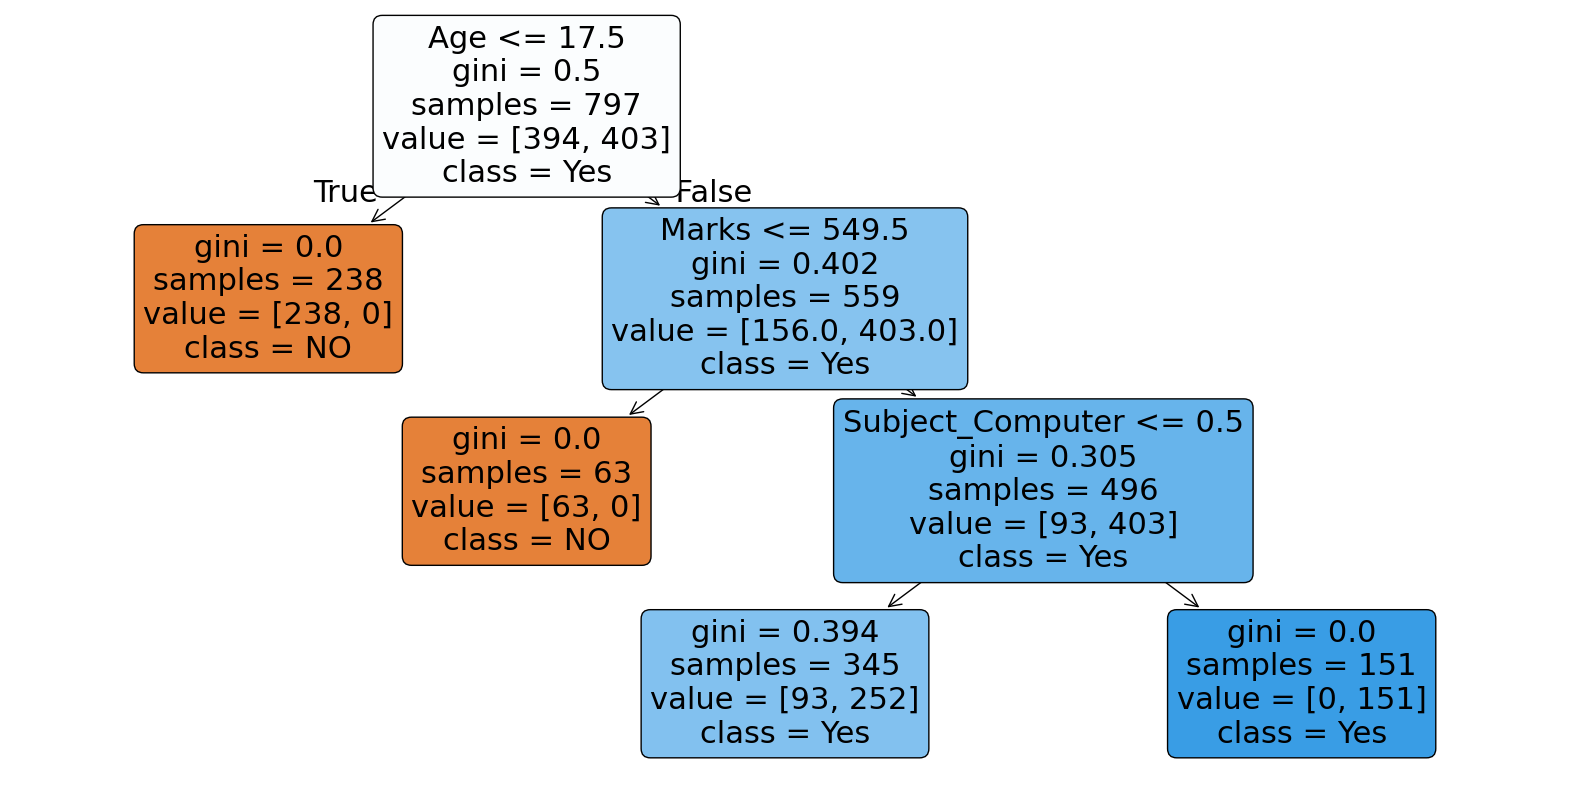

In [72]:
from sklearn.tree import plot_tree 
import matplotlib .pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(modeldt,feature_names=x.columns,class_names =['NO','Yes'],filled=True,rounded=True)
plt.show()




## random forest

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,max_depth=None,min_samples_split=2,min_samples_leaf=1,criterion='gini',random_state=42)
rf_model.fit(x_train,y_train)
y_pred7 = rf_model.predict(x_test)
print(y_pred7)

[1 1 0 0 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1
 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1
 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 1 0
 1 0 1 0 0 1 0 1 0 1 0 0 1 0 1]


In [74]:
print(accuracy_score(y_test,y_pred7))
print(confusion_matrix(y_test,y_pred7))
print(classification_report(y_test,y_pred7))




1.0
[[ 81   0]
 [  0 119]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00       119

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [75]:

train_score=  rf_model.score(x_train,y_train)
test_score = rf_model.score(x_test,y_test)
print("training accuracy:",train_score)
print("testing accuracy:",test_score)
difference = train_score - test_score
print("this is differe",difference)
if difference > 0.05:
    print("model overfitting ")
elif train_score <0.06 and test_score < 0.06:
    print("model is underfitting")
else:
    print("model is balanced")   
     


training accuracy: 1.0
testing accuracy: 1.0
this is differe 0.0
model is balanced


In [76]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model,x_train_scalar,y_train,cv=5)
print(scores)
print(scores.mean())

[0.81875    0.81875    0.8490566  0.8490566  0.78616352]
0.8243553459119497


## save model

In [77]:
import pickle
pickle.dump(modeldt,open("Admission_Model.pkl","wb"))